## 使用NumPy驗算

## 驗算平均數與標準差 是否跟 StandardScaler 類似

## 手動完成StandardScaler

In [2]:
import seaborn as sns
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

In [1]:
from sklearn.preprocessing import StandardScaler
data = [[-1, 2],
         [-0.5, 6], 
         [0, 10], 
         [1, 18]]
scaler = StandardScaler(with_mean=True,with_std=True)
scaler.fit(data)
print(scaler.mean_,scaler.var_)

[-0.125  9.   ] [ 0.546875 35.      ]


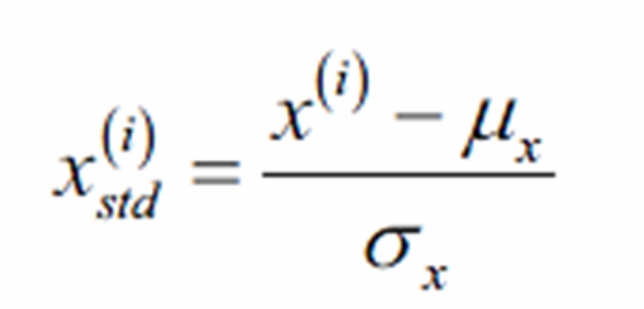

In [3]:
data_new = scaler.transform(data)
print(data_new)

[[-1.18321596 -1.18321596]
 [-0.50709255 -0.50709255]
 [ 0.16903085  0.16903085]
 [ 1.52127766  1.52127766]]


In [5]:
import numpy as np

In [ ]:
print(np.mean(data,axis=0))

array([-0.125,  9.   ])

In [12]:
print(np.var(data,axis=0))

[ 0.546875 35.      ]


In [14]:
ans = (data-np.mean(data,axis=0)) / np.std(data,axis=0)
print(ans)

[[-1.18321596 -1.18321596]
 [-0.50709255 -0.50709255]
 [ 0.16903085  0.16903085]
 [ 1.52127766  1.52127766]]


# 多重共線性(Multicollinearity)

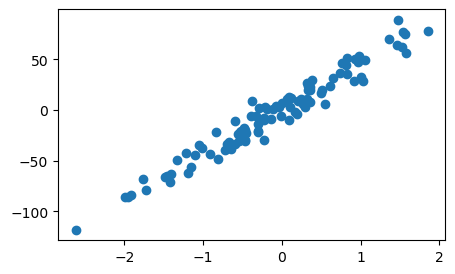

In [17]:
import seaborn as sns
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from sklearn.datasets import make_regression
X,y = make_regression(n_samples=100,n_features=1,noise=10,random_state=42)
plt.figure(figsize=(5,3))
plt.scatter(X,y)
plt.show()

(100, 1)
(100,)


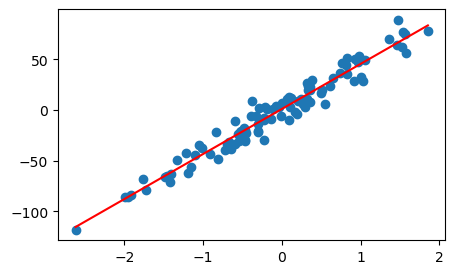

In [28]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X,y)
print(X.shape)
myX = X.reshape(-1)#陣列攤平成一維
print(myX.shape)
X_pred = np.linspace(np.min(myX),np.max(myX),20)
X_pred
y_pred = X_pred * model.coef_[0] + model.intercept_
plt.figure(figsize=(5,3))
plt.scatter(X,y)
plt.plot(X_pred,y_pred,c="red")
plt.show()

In [29]:
print(model.coef_[0], model.intercept_)

44.437169992254965 1.1651153205269718


## 產生X的共線資料

In [22]:
X2 = X.copy()
X_new = np.hstack((X,X2))
X_new[:10]

array([[ 0.93128012,  0.93128012],
       [ 0.08704707,  0.08704707],
       [-1.05771093, -1.05771093],
       [ 0.31424733,  0.31424733],
       [-0.47917424, -0.47917424],
       [ 0.64768854,  0.64768854],
       [-0.46341769, -0.46341769],
       [ 0.54256004,  0.54256004],
       [ 0.61167629,  0.61167629],
       [ 1.0035329 ,  1.0035329 ]])

In [23]:
from sklearn.linear_model import LinearRegression
mode = LinearRegression()
mode.fit(X_new,y)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [27]:
print(mode.coef_,mode.intercept_)

[22.218585 22.218585] 1.16511532052697


In [37]:
#無共線性
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
X,y = make_regression(n_samples=100,n_features=1,noise=10,random_state=42)
rng = np.random.default_rng(42)
X2 = rng.normal(0,1,size=X.shape)
X_new = np.hstack([X,X2])
X_train,X_test,y_train,y_test = train_test_split(X_new,y,test_size=0.4,random_state=42)
print(X_train.shape,X_test.shape,y_train.shape,y_test.shape)
rag_noise = np.random.default_rng(99)
X_test_noisy = X_test.copy()
X_test_noisy[:,1] += rag_noise.normal(0,0.3,size=X_test[:,1].shape)
model = LinearRegression()
model.fit(X_train,y_train)

(60, 2) (40, 2) (60,) (40,)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## 預測

In [38]:
pred = model.predict(X_test_noisy)
mse = mean_squared_error(y_test,pred)
print(f"mse:{mse}")

mse:91.01392151840545


In [45]:
#有共線性
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
X,y = make_regression(n_samples=100,n_features=1,noise=10,random_state=42)
rng = np.random.default_rng(42)
X2 = X + rng.normal(0,0.001,size=X.shape)
X_new = np.hstack([X,X2])
X_new

array([[ 0.93128012,  0.93158484],
       [ 0.08704707,  0.08600708],
       [-1.05771093, -1.05696048],
       [ 0.31424733,  0.3151879 ],
       [-0.47917424, -0.48112527],
       [ 0.64768854,  0.64638636],
       [-0.46341769, -0.46328985],
       [ 0.54256004,  0.5422438 ],
       [ 0.61167629,  0.61165949],
       [ 1.0035329 ,  1.00267985],
       [ 0.8219025 ,  0.8227819 ],
       [ 1.53803657,  1.53881436],
       [ 0.73846658,  0.73853261],
       [-0.21967189, -0.21854465],
       [-0.8084936 , -0.80802609],
       [ 0.09176078,  0.09090148],
       [-1.95967012, -1.95930137],
       [ 0.51326743,  0.51230855],
       [ 1.03099952,  1.03187797],
       [-2.6197451 , -2.61979503],
       [ 0.49671415,  0.49652929],
       [ 0.09707755,  0.09639662],
       [-0.46572975, -0.46450721],
       [ 0.91540212,  0.91524759],
       [ 1.56464366,  1.56421533],
       [ 1.46564877,  1.46529664],
       [-0.60063869, -0.60010638],
       [-0.03582604, -0.0354606 ],
       [-0.60170661,

In [46]:
X_train,X_test,y_train,y_test = train_test_split(X_new,y,test_size=0.4,random_state=42)
print(X_train.shape,X_test.shape,y_train.shape,y_test.shape)

rng_noise = np.random.default_rng(99)
X_test_noisy = X_test.copy()
X_test_noisy[:,1] += rag_noise.normal(0,0.3,size=X_test[:,1].shape)
model = LinearRegression()
model.fit(X_train,y_train)
pred = model.predict(X_test_noisy)
mse = mean_squared_error(y_test,pred)
print(f"mse:{mse}")

(60, 2) (40, 2) (60,) (40,)
mse:226841.2995903559


In [60]:
import pandas as pd
data = pd.read_csv("BMI.csv")
data.head()

,Gender,Height,Weight,Index
0,Male,174,96,4
1,Male,189,87,2
2,Female,185,110,4
3,Female,195,104,3
4,Male,149,61,3


In [61]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
# variance_inflation_factor 算出的越大共線性就越強
data["Gender"] = data["Gender"].map({"Male":0,"Female":1})
data.head()
X = data[["Gender","Height","Weight"]]
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
X


,Gender,Height,Weight
0,0,174,96
1,0,189,87
2,1,185,110
3,1,195,104
4,0,149,61
...,...,...,...
495,1,150,153
496,1,184,121
497,1,141,136
498,0,150,95


In [62]:
vif_data["VIF"] = [variance_inflation_factor(X.values,i) for i in range(len(X.columns))]

In [63]:
vif_data

,feature,VIF
0,Gender,2.028864
1,Height,11.623103
2,Weight,10.688377


In [64]:
X = data[["Gender","Height"]]
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns

In [65]:
vif_data["VIF"] = [variance_inflation_factor(X.values,i) for i in range(len(X.columns))]


In [66]:
vif_data

,feature,VIF
0,Gender,2.028417
1,Height,2.028417


# Sequential Feature Selection(SFS)

In [67]:
from sklearn.datasets import load_wine
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
import seaborn as sns
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

In [69]:
X,y = load_wine(return_X_y=True,as_frame=True)
X_train,X_test,y_train,y_test = train_test_split(X.values,y,test_size=0.3,random_state=42)
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((124, 13), (54, 13), (124,), (54,))

In [70]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)


In [71]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression()
clf.fit(X_train_std,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [72]:
clf.score(X_test_std,y_test)

0.9814814814814815